In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

### 1. Загрузите выборку из файла gbm-data.csv с помощью pandas и преобразуйте ее в массив numpy (параметр values у датафрейма). В первой колонке файла с данными записано, была или нет реакция. Все остальные колонки (d1 - d1776) содержат различные характеристики молекулы, такие как размер, форма и т.д. Разбейте выборку на обучающую и тестовую, используя функцию train_test_split с параметрами test_size = 0.8 и random_state = 241.

In [2]:
gbm_data = pd.read_csv('gbm-data.csv')
X_features = gbm_data.iloc[:, 1:].values
y_target = gbm_data.iloc[:, 0].values
X_training, X_testing, y_training, y_testing = train_test_split(
    X_features, y_target, test_size=0.8, random_state=241
)

### 2. Обучите GradientBoostingClassifier с параметрами n_estimators=250, verbose=True, random_state=241 и для каждого значения learning_rate из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее:
• Используйте метод staged_decision_function для предсказания качества на обучающей и тестовой выборке на каждой итерации.

• Преобразуйте полученное предсказание по формуле 1+e−y1_pred, где y_pred — предсказанное значение.

• Вычислите и постройте график значений log-loss на обучающей и тестовой выборках, а также найдите минимальное значение метрики и номер итерации, на которой оно достигается.

In [3]:
learning_rate_values = [1, 0.5, 0.3, 0.2, 0.1]
model_results = {'minimum_loss': np.inf, 'best_iteration': -1}

In [4]:
for rate in learning_rate_values:
    boosting_classifier = GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=rate,
        random_state=241,
        verbose=False
    )
    boosting_classifier.fit(X_training, y_training)
    
    # Вычисление log-loss на каждой итерации
    losses_on_test = []
    predictions_staged = boosting_classifier.staged_decision_function(X_testing)
    
    for stage_prediction in predictions_staged:
        sigmoid_output = 1.0 / (1.0 + np.exp(-stage_prediction))
        stage_loss = log_loss(y_testing, sigmoid_output)
        losses_on_test.append(stage_loss)
    
    # Фиксируем результаты для learning_rate=0.2
    if rate == 0.2:
        model_results['minimum_loss'] = min(losses_on_test)
        model_results['best_iteration'] = np.argmin(losses_on_test) + 1

# Сохранение ответов
with open('ans1.txt', 'w') as file:
    file.write('overfitting')
print("ans1: overfitting")

ans1: overfitting


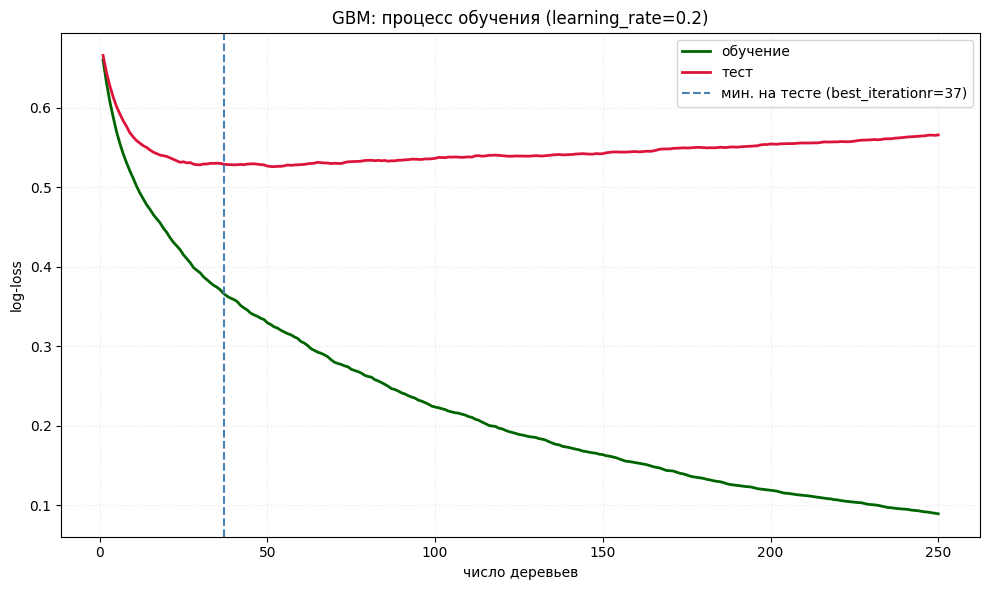

In [7]:
train_errors = []
for raw_scores in boosting_classifier.staged_decision_function(X_training):
    probs = 1.0 / (1.0 + np.exp(-raw_scores))
    train_errors.append(log_loss(y_training, probs))

fig, ax = plt.subplots(figsize=(10, 6))
iters = np.arange(1, 251)
ax.plot(iters, train_errors, color='darkgreen', linewidth=2, label='обучение')
ax.plot(iters, losses_on_test, color='crimson', linewidth=2, label='тест')
ax.axvline(x=model_results['best_iteration'], color='steelblue', linestyle='--', linewidth=1.5,
           label=f'мин. на тесте (best_iterationr={model_results["best_iteration"]})')
ax.set_xlabel('число деревьев')
ax.set_ylabel('log-loss')
ax.set_title(f'GBM: процесс обучения (learning_rate={0.2})')
ax.legend(loc='upper right')
ax.grid(alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()

### 4. Приведите минимальное значение log-loss на тестовой выборке и номер итерации, на котором оно достигается, при learning_rate = 0.2.

In [8]:
answer_2_text = f"{model_results['minimum_loss']:.2f} {model_results['best_iteration']}"
with open('ans2.txt', 'w') as file:
    file.write(answer_2_text)
print(f"ans2: {answer_2_text}")

ans2: 0.53 37


### 5. На этих же данных обучите RandomForestClassifier с количеством деревьев, равным количеству итераций, на котором достигается наилучшее качество у градиентного бустинга из предыдущего пункта, random_state=241 и остальными параметрами по умолчанию. Какое значение log-loss на тесте получается у этого случайного леса? (Не забывайте, что предсказания нужно получать с помощью функции predict_proba. В данном случае брать сигмоиду от оценки вероятности класса не нужно)

In [9]:
forest_classifier = RandomForestClassifier(
    n_estimators=model_results['best_iteration'],
    random_state=241
)
forest_classifier.fit(X_training, y_training)
forest_probabilities = forest_classifier.predict_proba(X_testing)[:, 1]
forest_logloss = log_loss(y_testing, forest_probabilities)

answer_3_text = f"{forest_logloss:.2f}"
with open('ans3.txt', 'w') as file:
    file.write(answer_3_text)
print(f"ans3: {answer_3_text}")

ans3: 0.54
